# Nexus AI - Multi-Feature OHLCV GAN
## Project: AI Driven Market Forecasting (PSX - OGDC)
**Objective:** Train a GAN to generate 30-day sequences of OHLCV (Open, High, Low, Close, Volume) data.

- **Generator:** LSTM (Input: Noise, Output: (30, 5) Sequence)
- **Discriminator:** LSTM (Input: (30, 5) Sequence, Output: Real/Fake)


In [1]:
# 1. Environment Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, RepeatVector, TimeDistributed, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
import os
from tensorflow.keras.layers import BatchNormalization, Dropout, GaussianNoise, Flatten,Input

# GPU Check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Enabled: {len(gpus)}")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ Running on CPU")

✅ GPU Enabled: 1


In [2]:
# 2. Load Data
FILE_NAME = 'ogdc_data.csv'

if os.path.exists(FILE_NAME):
    print(f"✅ Found local file: {FILE_NAME}")
    df = pd.read_csv(FILE_NAME)
else:
    print("📂 Local file not found. Please upload 'ogdc_data.csv'...")
    try:
        from google.colab import files
        uploaded = files.upload()
        import io
        df = pd.read_csv(io.BytesIO(uploaded[FILE_NAME]))
    except ImportError:
        raise FileNotFoundError(f"❌ Could not find {FILE_NAME} and not in Colab.")

# Ensure datetime
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')

print(f"✅ Loaded {len(df)} rows.")
print(df.head())

📂 Local file not found. Please upload 'ogdc_data.csv'...


Saving ogdc_data.csv to ogdc_data.csv
✅ Loaded 1223 rows.
        date    open    high     low   close   volume
0 2021-03-01  105.15  105.45  103.40  104.48   993856
1 2021-03-02  104.00  107.00  103.71  105.40  1627498
2 2021-03-03  105.99  106.70  104.05  106.22   849105
3 2021-03-04  103.50  106.00  103.50  104.28  1610733
4 2021-03-05  106.40  108.40  104.25  107.10  1858659


## 3. Preprocessing (OHLCV)
We use all 5 features: `open`, `high`, `low`, `close`, `volume`.

In [3]:
# Feature Selection
features = ['open', 'high', 'low', 'close', 'volume']
data = df[features].values

# Normalize to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create Sliding Windows
SEQ_LEN = 30

def create_sequences(dataset, seq_len):
    seqs = []
    for i in range(len(dataset) - seq_len):
        seqs.append(dataset[i:i+seq_len])
    return np.array(seqs)

X_train = create_sequences(scaled_data, SEQ_LEN)

# Dimensions: (samples, time_steps, features)
print(f"Training Data Shape: {X_train.shape}") # Should be (N, 30, 5)

Training Data Shape: (1193, 30, 5)


## 4. Model Architecture

In [4]:
LATENT_DIM = 100
SEQ_LEN = 30
NUM_FEATURES = 5  # OHLCV

# --- Generator (The Artist) ---
def build_generator():
    model = Sequential(name="Generator")

    # FIX 1: Explicit Input Layer (Solves the "batch_shape" Error)
    model.add(Input(shape=(LATENT_DIM,)))

    # Layer 1: Map Latent Noise to Feature Space
    model.add(Dense(128))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))  # Keeps the line wavy

    # Reshape for LSTM
    model.add(RepeatVector(SEQ_LEN))

    # Layer 2: LSTM
    model.add(LSTM(128, return_sequences=True))
    model.add(BatchNormalization(momentum=0.8))  # Keeps the line wavy

    # Layer 3: Extra LSTM for Depth
    model.add(LSTM(64, return_sequences=True))
    model.add(BatchNormalization(momentum=0.8))

    # Output Layer
    model.add(TimeDistributed(Dense(NUM_FEATURES, activation='sigmoid')))

    return model

In [5]:
# --- Discriminator (The Critic) ---
def build_discriminator():
    model = Sequential(name="Discriminator")

    # FIX 1: Explicit Input Layer (Solves the "batch_shape" Error)
    model.add(Input(shape=(SEQ_LEN, NUM_FEATURES)))

    # FIX 2: Add Noise so Discriminator isn't too strict
    model.add(GaussianNoise(0.1))

    # Layer 1: LSTM
    model.add(LSTM(128, return_sequences=True))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3)) # Prevents memorization

    # Flatten & Classify
    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    # Compile
    optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

In [6]:
# --- Build & Compile GAN ---
def build_gan(generator, discriminator):
    discriminator.trainable = False

    model = Sequential(name="GAN")
    model.add(generator)
    model.add(discriminator)

    optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=optimizer)

    return model

# Initialize
generator = build_generator()
discriminator = build_discriminator()
gan = build_gan(generator, discriminator)

print("✅ Model Rebuilt: Version-Safe & Volatility-Tuned.")
gan.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


✅ Model Rebuilt: Version-Safe & Volatility-Tuned.


Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Generator (Sequential)          │ (None, 30, 5)          │       195,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │        72,449 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,974 (1.02 MB)

 Trainable params: 194,885 (761.27 KB)

 Non-trainable params: 73,089 (285.50 KB)

## 5. Training Loop

Starting Training...


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0: [D loss: 0.6994] [G loss: 0.7009]


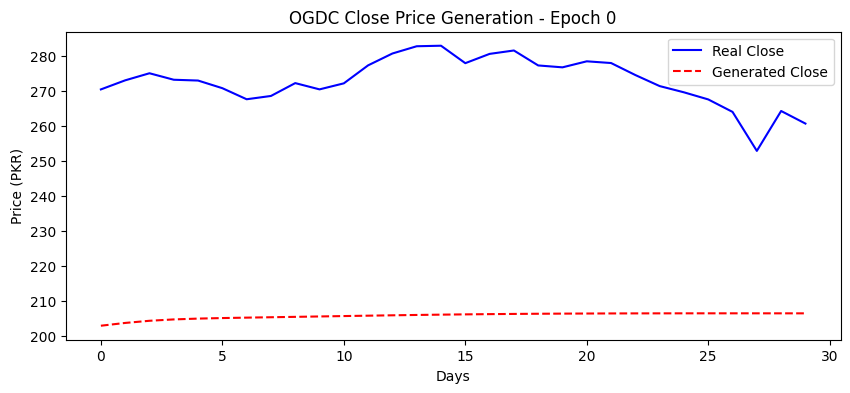

Epoch 100: [D loss: 0.6911] [G loss: 0.7016]


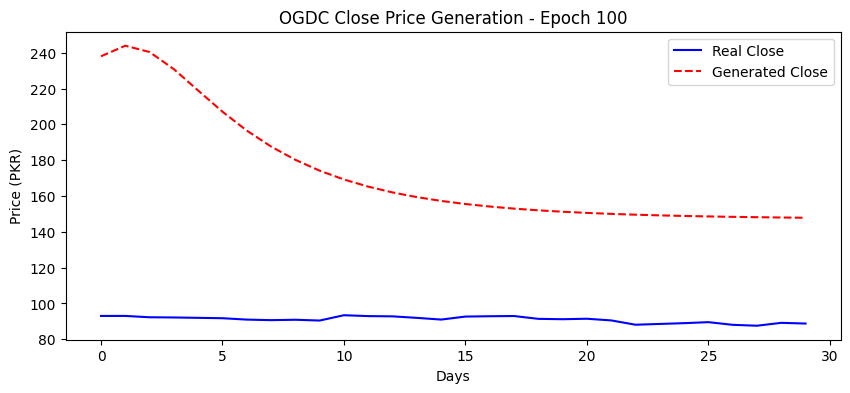

Epoch 200: [D loss: 0.6926] [G loss: 0.6988]


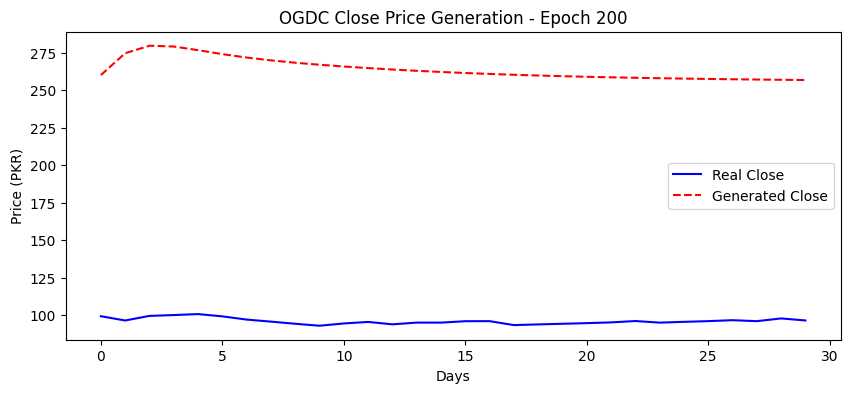

Epoch 300: [D loss: 0.6940] [G loss: 0.6958]


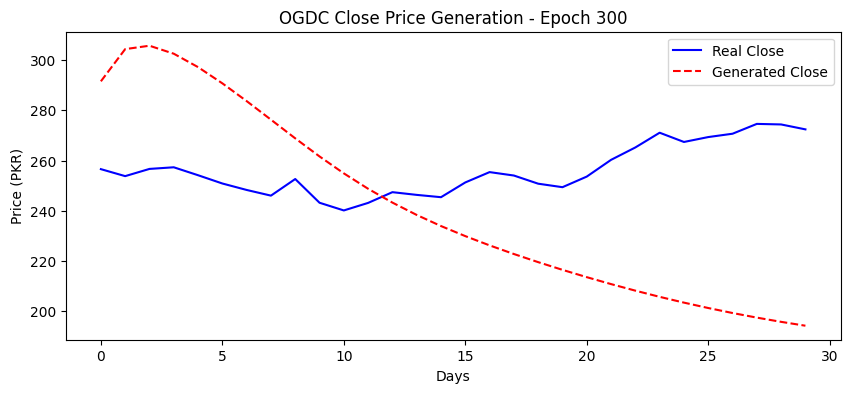

Epoch 400: [D loss: 0.6962] [G loss: 0.6912]


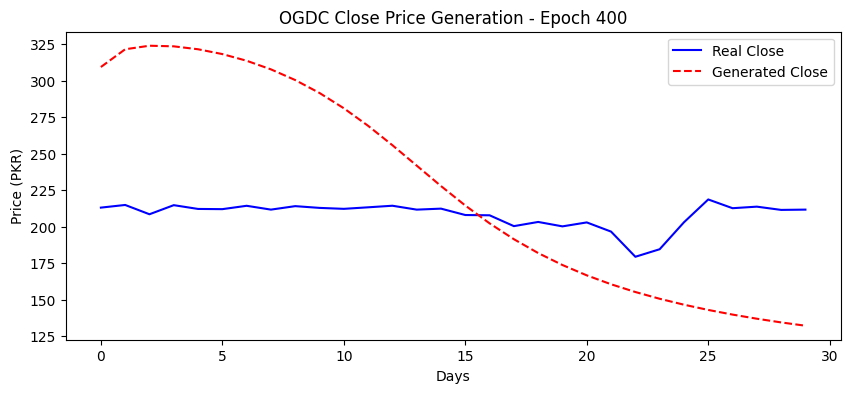

Epoch 500: [D loss: 0.6997] [G loss: 0.6842]


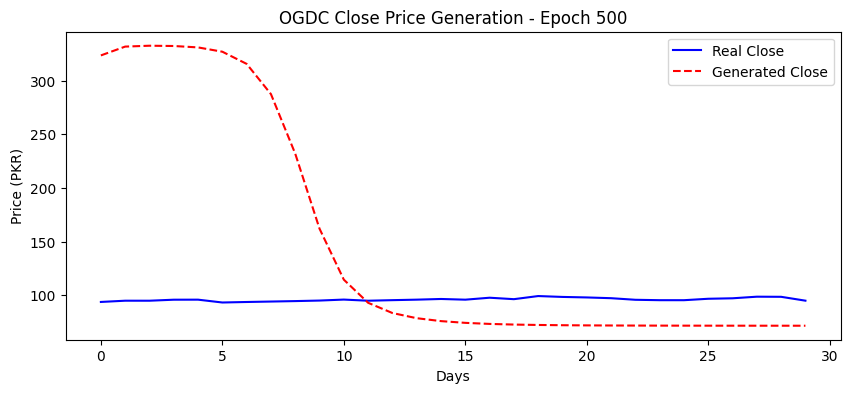

Epoch 600: [D loss: 0.7034] [G loss: 0.6772]


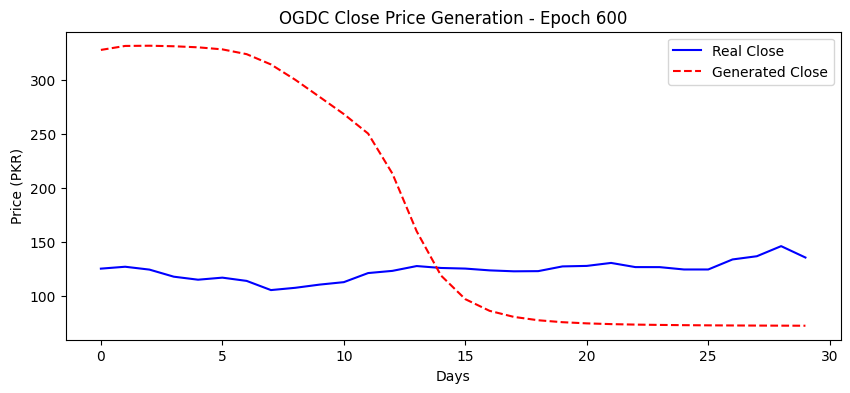

Epoch 700: [D loss: 0.7064] [G loss: 0.6713]


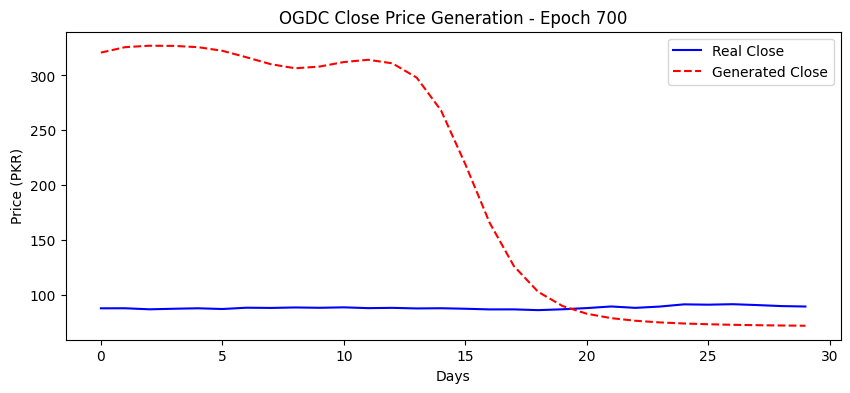

Epoch 800: [D loss: 0.7092] [G loss: 0.6663]


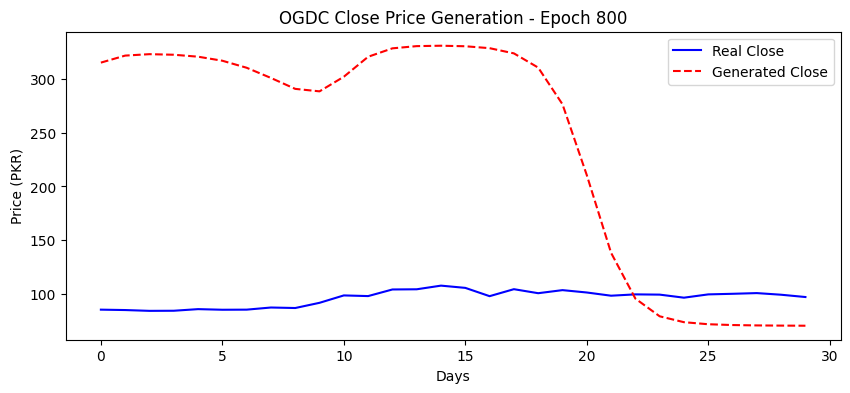

Epoch 900: [D loss: 0.7115] [G loss: 0.6619]


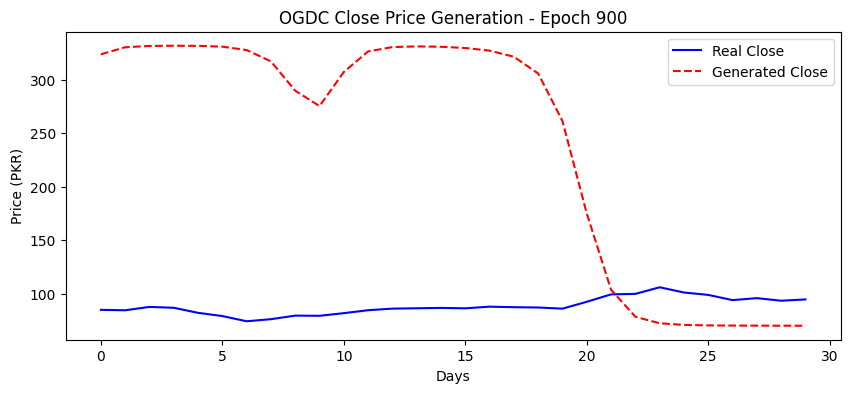

In [7]:
# --- IMPROVED TRAINING LOOP (With Soft Labels) ---

EPOCHS = 1000
BATCH_SIZE = 32
half_batch = BATCH_SIZE // 2

print("Starting Training...")

for epoch in range(EPOCHS):
    # ---------------------
    #  Train Discriminator
    # ---------------------

    # 1. Select real samples
    idx = np.random.randint(0, X_train.shape[0], half_batch)
    real_seqs = X_train[idx]

    # 2. Generate fake samples
    noise = np.random.normal(0, 1, (half_batch, LATENT_DIM))
    gen_seqs = generator.predict(noise, verbose=0)

    # 3. Create Labels (WITH SOFT LABELS)
    # Instead of strict 1.0, use 0.9 to 1.0 (This helps Generator learn)
    real_y = np.random.uniform(0.9, 1.0, (half_batch, 1)) # <--- TWEAK 1: Soft Labels
    fake_y = np.zeros((half_batch, 1))                    # Fake is still 0

    # 4. Train
    d_loss_real = discriminator.train_on_batch(real_seqs, real_y)
    d_loss_fake = discriminator.train_on_batch(gen_seqs, fake_y)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

    # ---------------------
    #  Train Generator
    # ---------------------

    noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    valid_y = np.ones((BATCH_SIZE, 1)) # Generator still wants to trick D into thinking it's 1.0

    g_loss = gan.train_on_batch(noise, valid_y)

    # ---------------------
    #  Visualization
    # ---------------------
    if epoch % 100 == 0:
        # Handle cases where loss might be a list or scalar
        d_acc = d_loss[1] * 100 if isinstance(d_loss, list) or isinstance(d_loss, np.ndarray) else 0
        d_val = d_loss[0] if isinstance(d_loss, list) or isinstance(d_loss, np.ndarray) else d_loss

        print(f"Epoch {epoch}: [D loss: {d_val:.4f}] [G loss: {g_loss:.4f}]")

        # Generate one sample for plotting
        test_noise = np.random.normal(0, 1, (1, LATENT_DIM))
        gen_seq = generator.predict(test_noise, verbose=0)[0] # Shape: (30, 5)

        # Inverse transform to get original scale (OHLCV)
        gen_unscaled = scaler.inverse_transform(gen_seq)

        # Get a real sample for comparison
        real_sample_scaled = X_train[np.random.randint(0, len(X_train))]
        real_unscaled = scaler.inverse_transform(real_sample_scaled)

        # Plotting 'Close' Price (Index 3)
        plt.figure(figsize=(10, 4))
        plt.plot(real_unscaled[:, 3], label='Real Close', color='blue')
        plt.plot(gen_unscaled[:, 3], label='Generated Close', color='red', linestyle='--')
        plt.title(f"OGDC Close Price Generation - Epoch {epoch}")
        plt.xlabel("Days")
        plt.ylabel("Price (PKR)")
        plt.legend()
        plt.show()

In [8]:
# Save Model
generator.save('gan_generator_ohlcv.h5')
print("Model Saved: gan_generator_ohlcv.h5")

Model Saved: gan_generator_ohlcv.h5
